In [ ]:
# Import libraries

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from collections import Counter

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load dataset

df = pd.read_excel(
    "/content/osha 4470 (with additional metadata scraped from narrative site).xlsx",
    sheet_name="super2"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# Display basic information

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4470, 10)


,id,title,SUMMARY,industry,diagnosis,occupation,1st occupation,fall dist,cause,fatcause
0,200361855,Two Workers Are Struck By Motor Vehicle And One Is Killed,On August 27 2013 Employees #1 and #2 of Templar Inc. a construction company specializing in fiber optic installation and services were working along a highway. The highway speed limit was posted at 55 miles per hour. Employee #1 was marking the location of an underground line that ran below the turn lane. Employee #2 was next to Employee #1 and performing the duties of a flagger. A privately owned vehicle was travelling in the travel/through lane. The vehicle veered to the right entered the turn lane and struck both workers. Emergency medical services were called. Employee #1 was declared dead at the scene. Employee #2 refused emergency medical treatment for the bruises he received when struck.,1623,",Other,Other",",Occupation not reported,Occupation not reported",Occupation not reported,-1,Traffic protection,Other
1,202673471,Foreman Is Fatally Crushed When Forklift Tips Over,At approximately 6:30 a.m. on May 13 2013 Employee #1 a foreman regularly employed by Integrity Rebar Placers was operating a rough terrain forklift at a contracted job site in Murrieta CA. He was using the forklift to move bundles of steel. Employee #1 was positioning the forklift to pick up another load when the forklift tipped back and over. Employee #1 exited the cab of the forklift as the machine tipped over. The forklift fell on top of Employee #1 pinning him under the lower section of the boom and crushing his abdomen. He was killed. The employer notified Cal/OSHA of this fatality at approximately 8:35 a.m. on May 13 2013. The subsequent investigation determined that Employee #1 had been employed by the company for approximately 2.5 months.,1791,",Fracture",",Supervisors, material moving equipment operators",Supervisors,-1,[],[]
2,202509832,Employee Suffers Abdominal Fracture In Fall From Ladder,On April 9 2013 Employee #1 was installing vinyl sidings on a single story residence. The employee was standing an A-frame ladder that was set on a plank of a scaffold. The scaffold moved causing Employee #1 to lose his balance. The employee fell from the ladder approximately 12-ft to the ground. Employee #1 was transported to an area hospital where he was treated for an abdominal fracture. The employee remained hospitalized.,1521,",Fracture",",Carpenters",Carpenters,8,Exterior carpentry,Fall from/with ladder
3,201562840,Employee'S Body Is Caught In Asphalt Machine Dies,On November 27 2012 Employee #1 was operating an asphalt-pulverizing machine. The employee's work clothing zipper was caught in the asphalt-pulverizing machine pulling his body into the squeeze point action of the machine. Employee #1 was amputated from the abdominal point of his body. The employee was pronounced dead at the scene.,1611,",Amputation",",Construction laborers",Construction laborers,-1,Excavation,Crushed/run
4,202478632,Employee Is Punctured In Abdomen With Nail,At approximately 11:57 a.m. on September 28 2012 Employee #1 was working with a coworker. Their job was to replace the felt under the concrete tile at the residential location. Once the felt was replaced the employees would put the tile back into place. Employee #1 removed debris from a roof and dumping leftover roof tile into a dumpster on the ground. His coworker the foreman was using a Bostitch nail gun (Model Number F21PL Serial Number 12194029B) to insert nails into roofing tiles. After the felt was replaced the employees would put the tile back in place. While walking on the pitch of the roof Employee #1 was carrying a load of leftover tile when he slipped and fell into his coworker. The coworker tried to catch Employee #1 but the nail gun went off sending a nail into Employee #1's abdomen. Employee #1 was transported to a medical center where he underwent surgical procedures and was hospitalized for postoperative care.,1761,",Puncture",",Occupation not rep

In [ ]:
# Select a random sample of 1000 records

df = df.sample(n=1000, random_state=42).reset_index(drop=True)

print("Sample Dataset Shape:", df.shape)

Sample Dataset Shape: (1000, 10)


In [ ]:
# Save sampled dataset

df.to_csv("osha_sample_1000.csv", index=False)

print("Sample dataset saved successfully.")

Sample dataset saved successfully.


In [ ]:
# Display dataset shape

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1000
Number of Columns: 10


In [ ]:
# Display first five records

df.head()

,id,title,SUMMARY,industry,diagnosis,occupation,1st occupation,fall dist,cause,fatcause
0,200641033,Employee Killed In Fall Through Skylight Hole,At 7:30 a.m. on March 30 1999 Employee #1 and three coworkers were installing new skylights on a single-story renovated warehouse with a new metal roof deck. The 24 skylight holes were 35 in. by 109 in. and had been covered with plywood. Employee #1 and a coworker started installing the first skylight on the northwest roof corner. They pulled back the plywood cover from half of the skylight hole and at approximately 9:30 a.m. set in the lower 35 in. by 55 in. fiberglass panel. They were installing insulating material when Employee #1 inadvertently stepped into the skylight hole. The fiberglass bottom pan could not support his weight and he fell approximately 33 ft to the concrete floor of the warehouse. Employee #1 was killed. None of the crew members were using their personal fall protection systems.,1541,",Concussion",",Occupation not reported",Occupation not reported,33,[],Fall from roof
1,201350667,One Employee Killed Second Injured When Mast Platform Fell,Employee #1 was killed and Employee #2 was seriously injured and hospitalized when they were on an HEK MSM 1000 mast climbing work platform which fell approximately 60 feet to the ground. The employer failed to ensure that the limit switch actuating rail also known as the red painted top mast was installed on the supporting mast before the platform was used. The red painted top mast actuates the limit switch of the motor which prevents the platform from traveling upwards. Because this portion of the mast was missing the platform was not prevented from being lifted beyond its supporting mast and falling to the ground.,1799,",Concussion,Other",",Occupation not reported,Occupation not reported",Occupation not reported,60,Waterproofing,Fall from/with scaffold
2,202675096,Worker Falls From Roof And Sustains Multiple Fractures,On May 20 2013 Employee #1 a roofer and Coworker #1 both employed by a roofing contractor were working at a residential building. They had removed the existing shake roof and were installing Oriented Strand Board (OSB) sheathing in preparation for installing a composition roof. The roof pitch measured 4/12. Employee #1 and Coworker #1 had removed approximately 10 OSB sheets from a stack of 38 sheets when for reasons unknown a brace identified as one of two OSB stickers holding the stack on the roof (one sticker on each end of the stack) broke. Ten sheets of sheathing slid off the roof. Employee #1 who was working below the stack was struck by the falling sheets and thrown off the roof. He fell from an eave height of 9 feet. Emergency services were called and the Sacramento Fire Department responded. Employee #1 was transported to University of California Davis Medical Center in Sacramento. He was treated for a compound fracture of his right wrist a fractured hip and a fractured pelvis. He required four days hospitalization. This fall was reported on May 20 3013 by the Sacramento Fire Department to Cal/OSHA's Sacramento District Office. The employer did not report. The subsequent investigation determined that the OSB sheets had been stacked and secured on the roof by a third party delivery company. The roofing crew had inspected the stack of OSB sheets that morning and reported that it was secured.,1761,",Fracture",",Roofers",Roofers,9,Roofing,Fall from roof
3,201773348,Roofer Falls 40 Feet And Dies While Wearing Ppe,On February 17 2009 Employee #1 a 51-year-old male construction worker with Heldreth Construction was working approximately forty-feet above the ground installing roof decking. Employee #1 was using a harness and retractable lanyard attached to a roof anchor when he fell. The force of the fall pulled the anchor away from the decking to which it was attached allowing the employee to fall. Employee #1 was killed in the fall.,1791,",Other",",Construction trades, n.e.c.",Construction trades,40,[],Fall f

In [ ]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1000 non-null   int64 
 1   title           1000 non-null   object
 2   SUMMARY         1000 non-null   object
 3   industry        1000 non-null   int64 
 4   diagnosis       1000 non-null   object
 5   occupation      1000 non-null   object
 6   1st occupation  997 non-null    object
 7   fall dist       1000 non-null   int64 
 8   cause           1000 non-null   object
 9   fatcause        1000 non-null   object
dtypes: int64(3), object(7)
memory usage: 78.3+ KB


In [ ]:
# Display data types

df.dtypes

,0
id,int64
title,object
SUMMARY,object
industry,int64
diagnosis,object
occupation,object
1st occupation,object
fall dist,int64
cause,object
fatcause,object


In [ ]:
# Check missing values

missing_values = df.isnull().sum()

missing_values

,0
id,0
title,0
SUMMARY,0
industry,0
diagnosis,0
occupation,0
1st occupation,3
fall dist,0
cause,0
fatcause,0


In [ ]:
# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [ ]:
# Display descriptive statistics for numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000.0,1.874782e+08,5.199235e+07,568428.0,200589833.0,201185576.0,2.024420e+08,362661902.0
industry,1000.0,1.699164e+03,9.100585e+01,1521.0,1623.0,1731.0,1.771000e+03,1799.0
fall dist,1000.0,8.348000e+00,3.532385e+01,-1.0,-1.0,-1.0,8.000000e+00,720.0


In [ ]:
# Display descriptive statistics for categorical columns

df.describe(include="object").T

,count,unique,top,freq
title,1000,924,Electric Shock,51
SUMMARY,1000,1000,On November 12 2008 Employee #1 a construction worker and the coworkers were demolishing an escalator in an old department store. The day prior to the accident the same employees disassembled the escalator by removing the motor steps wheels and related parts remaining only the trusses. On the day of the accident Employee #1 threw the steps from the third floor to the first one so the steps could be loaded into a truck and transported off site. Employee #1 fell over the edge and was killed. He was working at an unprotected landing of the escalator on the third floor.,1
diagnosis,1000,66,",Fracture",281
occupation,1000,112,",Occupation not reported",326
1st occupation,997,72,Occupation not reported,365
cause,1000,41,[],472
fatcause,1000,29,[],197


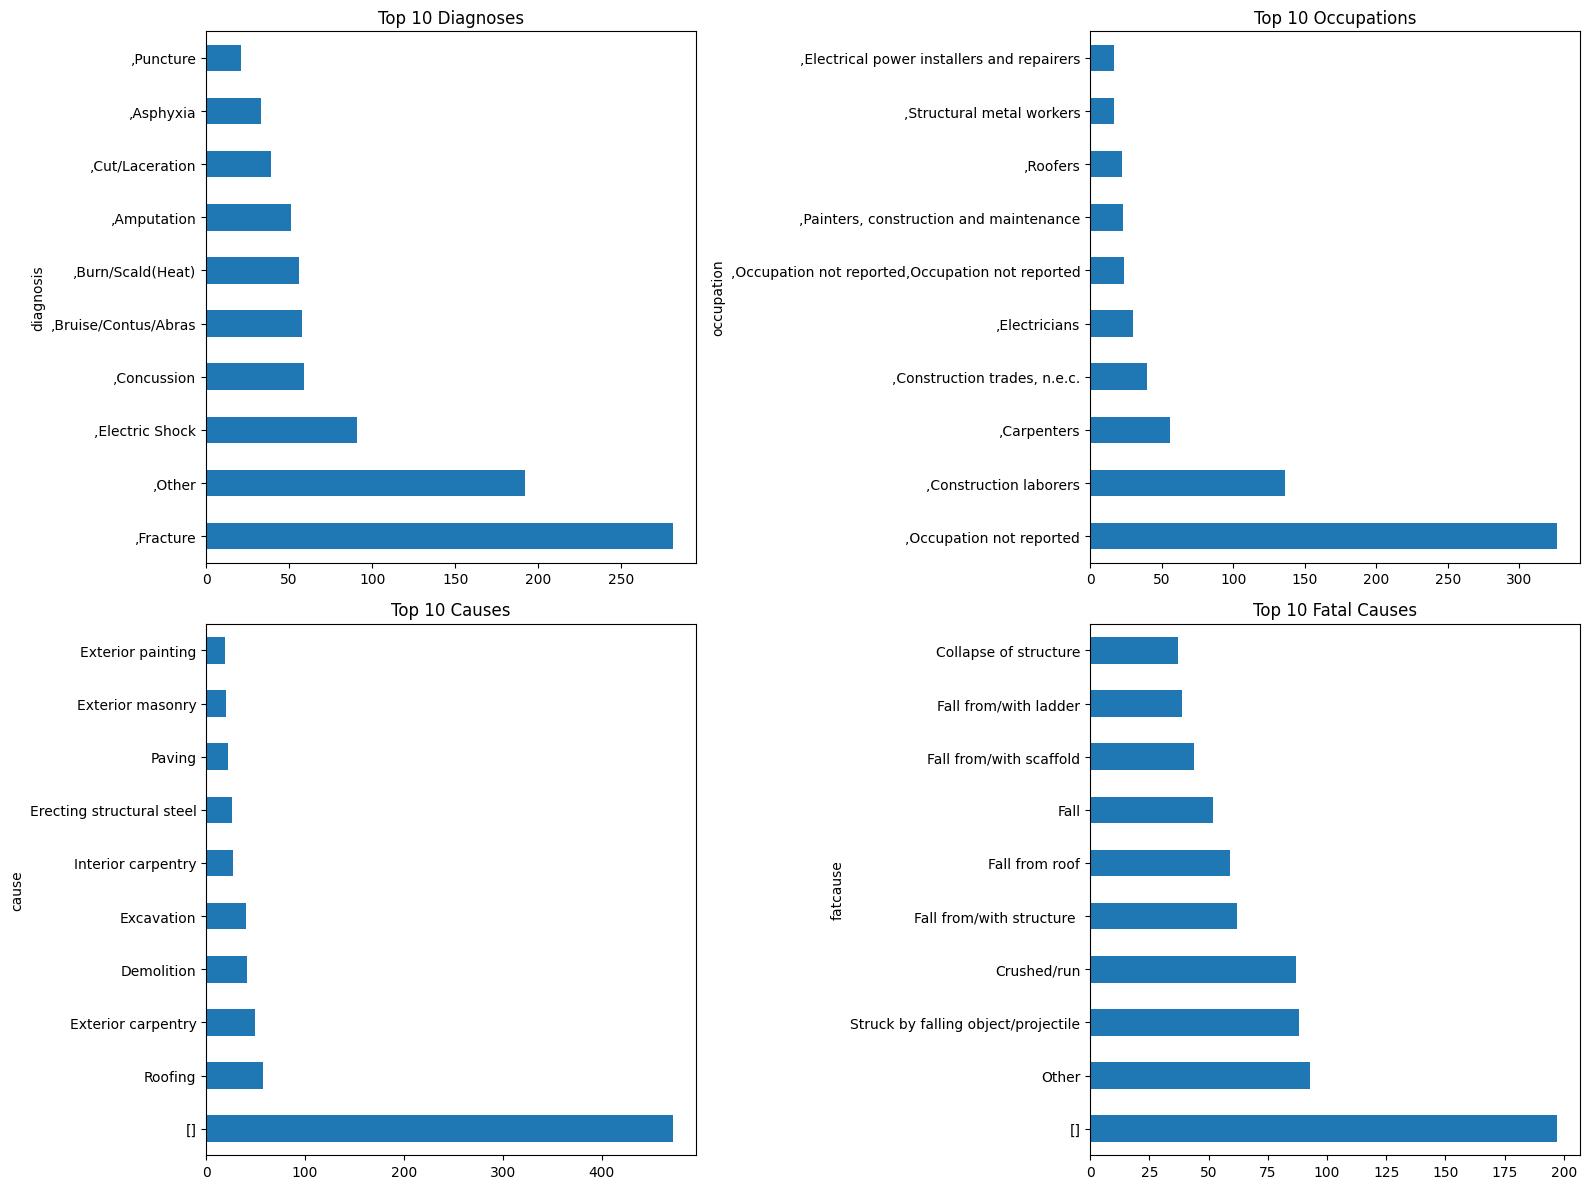

In [ ]:
# Visualize categorical feature distributions

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df["diagnosis"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[0, 0],
    title="Top 10 Diagnoses"
)

df["occupation"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[0, 1],
    title="Top 10 Occupations"
)

df["cause"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[1, 0],
    title="Top 10 Causes"
)

df["fatcause"].value_counts().head(10).plot(
    kind="barh",
    ax=axes[1, 1],
    title="Top 10 Fatal Causes"
)

plt.tight_layout()
plt.show()

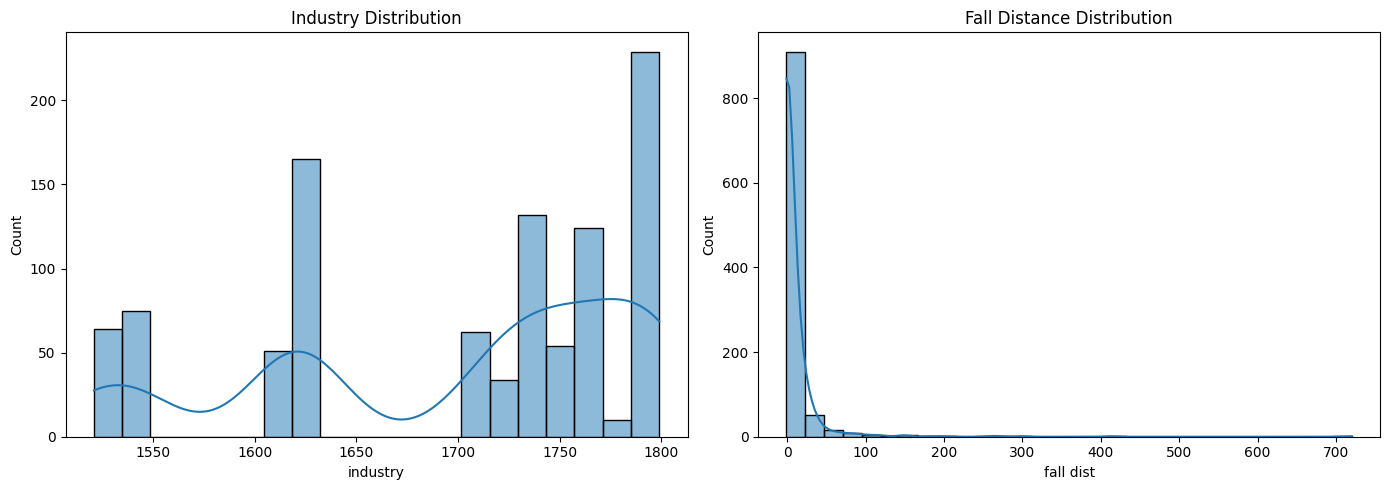

In [ ]:
# Visualize numerical feature distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["industry"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Industry Distribution")

sns.histplot(df["fall dist"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Fall Distance Distribution")

plt.tight_layout()
plt.show()

count    1000.000000
mean      116.504000
std        81.967815
min        12.000000
25%        60.000000
50%        97.000000
75%       149.000000
max       675.000000
Name: text_length, dtype: float64


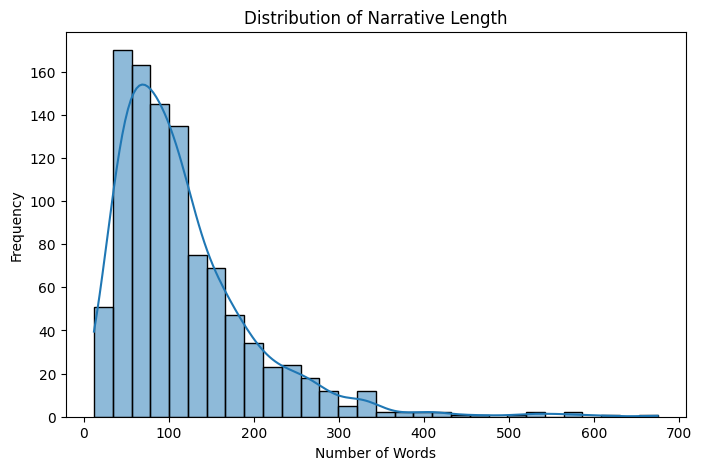

In [ ]:
# Analyze narrative length

df["text_length"] = df["SUMMARY"].str.split().str.len()

print(df["text_length"].describe())

plt.figure(figsize=(8, 5))

sns.histplot(df["text_length"], bins=30, kde=True)

plt.title("Distribution of Narrative Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

,Word,Frequency
0,the,10073
1,a,4197
2,was,4020
3,and,3566
4,employee,3358
5,to,3256
6,of,2751
7,on,2229
8,he,1716
9,in,1399


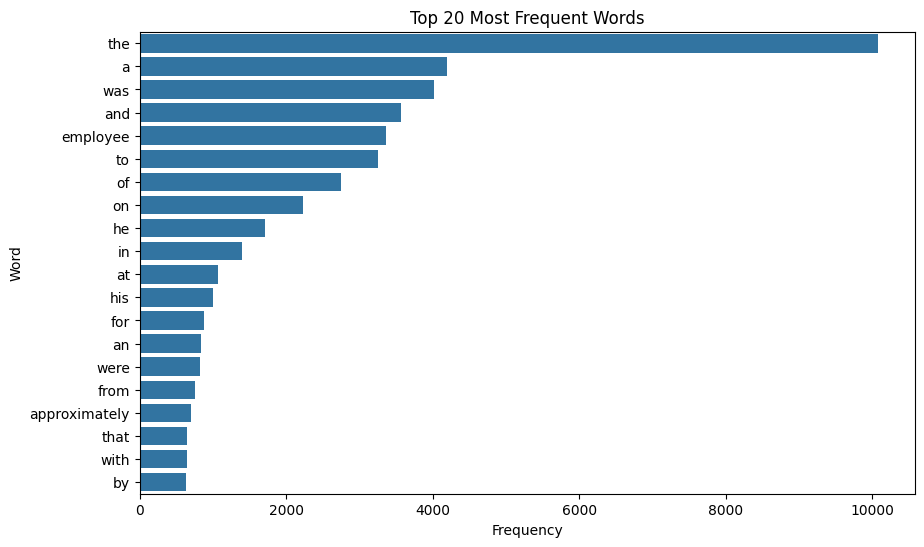

In [ ]:
# Display most frequent words

text = " ".join(df["SUMMARY"].astype(str))

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

word_counts = Counter(words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")

plt.show()

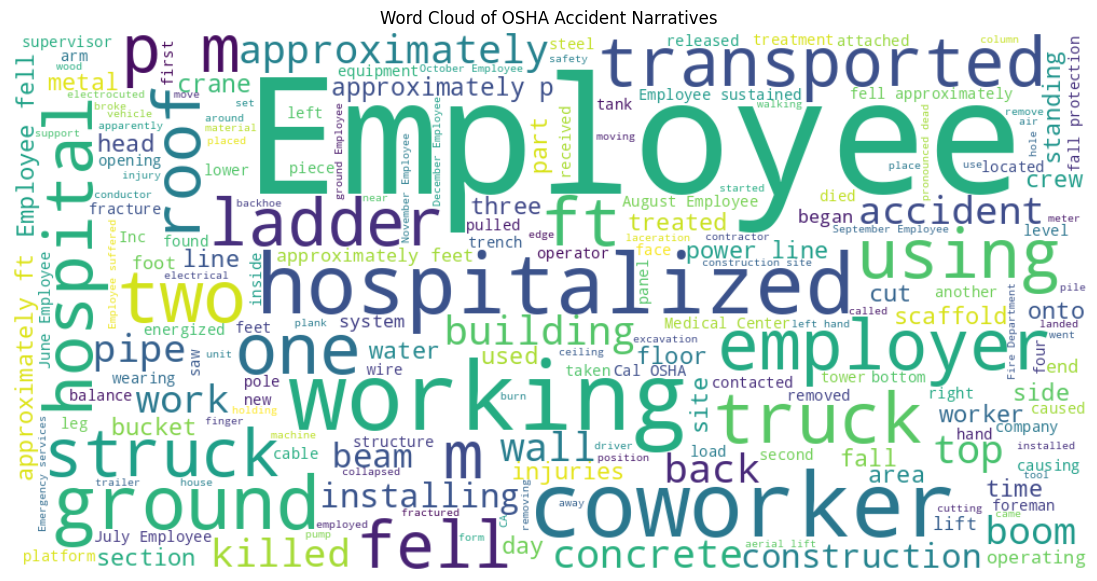

In [ ]:
# Generate word cloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of OSHA Accident Narratives")

plt.show()

In [ ]:
# Download NLTK resources

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Clean accident narratives

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"\d+", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["clean_summary"] = df["SUMMARY"].apply(preprocess_text)

print("Text preprocessing completed.")

Text preprocessing completed.


In [ ]:
# Compare original and cleaned narratives

comparison = df[["SUMMARY", "clean_summary"]]

comparison.head()

,SUMMARY,clean_summary
0,At 7:30 a.m. on March 30 1999 Employee #1 and three coworkers were installing new skylights on a single-story renovated warehouse with a new metal roof deck. The 24 skylight holes were 35 in. by 109 in. and had been covered with plywood. Employee #1 and a coworker started installing the first skylight on the northwest roof corner. They pulled back the plywood cover from half of the skylight hole and at approximately 9:30 a.m. set in the lower 35 in. by 55 in. fiberglass panel. They were installing insulating material when Employee #1 inadvertently stepped into the skylight hole. The fiberglass bottom pan could not support his weight and he fell approximately 33 ft to the concrete floor of the warehouse. Employee #1 was killed. None of the crew members were using their personal fall protection systems.,march employee three coworkers installing new skylight singlestory renovated warehouse new metal roof deck skylight hole covered plywood employee coworker started installing first skylight northwest roof corner pulled back plywood cover half skylight hole approximately set lower fiberglass panel installing insulating material employee inadvertently stepped skylight hole fiberglass bottom pan could support weight fell approximately concrete floor warehouse employee killed none crew member using personal fall protection system
1,Employee #1 was killed and Employee #2 was seriously injured and hospitalized when they were on an HEK MSM 1000 mast climbing work platform which fell approximately 60 feet to the ground. The employer failed to ensure that the limit switch actuating rail also known as the red painted top mast was installed on the supporting mast before the platform was used. The red painted top mast actuates the limit switch of the motor which prevents the platform from traveling upwards. Because this portion of the mast was missing the platform was not prevented from being lifted beyond its supporting mast and falling to the ground.,employee killed employee seriously injured hospitalized hek msm mast climbing work platform fell approximately foot ground employer failed ensure limit switch actuating rail also known red painted top mast installed supporting mast platform used red painted top mast actuates limit switch motor prevents platform traveling upwards portion mast missing platform prevented lifted beyond supporting mast falling ground
2,On May 20 2013 Employee #1 a roofer and Coworker #1 both employed by a roofing contractor were working at a residential building. They had removed the existing shake roof and were installing Oriented Strand Board (OSB) sheathing in preparation for installing a composition roof. The roof pitch measured 4/12. Employee #1 and Coworker #1 had removed approximately 10 OSB sheets from a stack of 38 sheets when for reasons unknown a brace identified as one of two OSB stickers holding the stack on the roof (one sticker on each end of the stack) broke. Ten sheets of sheathing slid off the roof. Employee #1 who was working below the stack was struck by the falling sheets and thrown off the roof. He fell from an eave height of 9 feet. Emergency services were called and the Sacramento Fire Department responded. Employee #1 was transported to University of California Davis Medical Center in Sacramento. He was treated for a compound fracture of his right wrist a fractured hip and a fractured pelvis. He required four days hospitalization. This fall was reported on May 20 3013 by the Sacramento Fire Department to Cal/OSHA's Sacramento District Office. The employer did not report. The subsequent investigation determined that the OSB sheets had been stacked and secured on the roof by a third party delivery company. The roofing crew had inspected the stack of OSB sheets that morning and reported that it was secured.,may employee roofer coworker employed roofing contractor working residential building removed existing shake roof installing oriented strand board osb sheathing prep

In [ ]:
# Analyze cleaned narrative length

df["clean_length"] = df["clean_summary"].str.split().str.len()

print(df["clean_length"].describe())

count    1000.000000
mean       59.052000
std        42.378854
min         5.000000
25%        31.000000
50%        49.000000
75%        74.000000
max       349.000000
Name: clean_length, dtype: float64


,Word,Frequency
0,employee,3693
1,approximately,700
2,fell,474
3,working,453
4,foot,401
5,hospitalized,338
6,ground,330
7,line,317
8,coworker,314
9,concrete,310


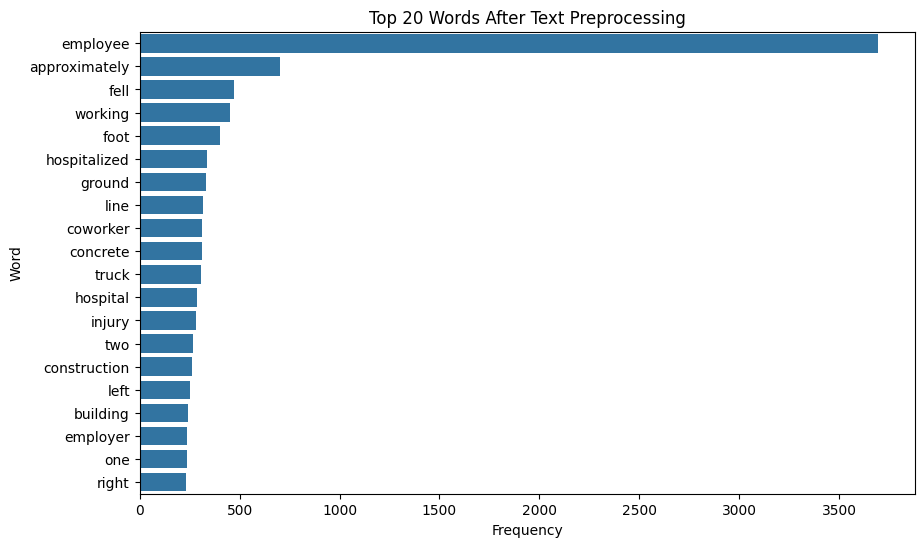

In [ ]:
# Display most frequent cleaned words

clean_text = " ".join(df["clean_summary"])

clean_words = clean_text.split()

clean_word_counts = Counter(clean_words)

common_clean_words = pd.DataFrame(
    clean_word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_clean_words)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_clean_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Words After Text Preprocessing")

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

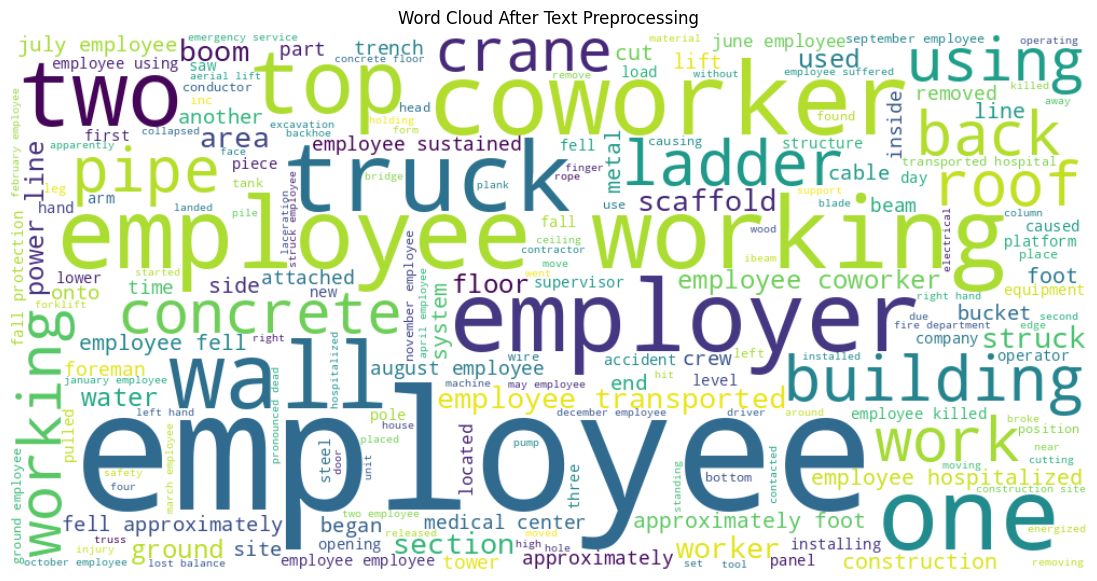

In [ ]:
# Generate cleaned word cloud

clean_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text)

plt.figure(figsize=(14, 7))

plt.imshow(clean_wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud After Text Preprocessing")

plt.show()

In [ ]:
# Define unsafe condition keywords

unsafe_condition_keywords = [
    "collapse", "collapsed", "structure", "scaffold", "roof",
    "ladder", "trench", "excavation", "electrical", "energized",
    "equipment", "machine", "forklift", "crane", "boom",
    "vehicle", "fall", "falling", "struck", "crushed",
    "object", "beam", "pipe", "wall", "floor",
    "platform", "opening", "hole", "concrete", "material",
    "defective", "faulty", "damaged", "broken", "failure"
]

# Define unsafe act keywords

unsafe_act_keywords = [
    "operate", "operating", "using", "used", "work", "working",
    "climb", "climbing", "walk", "walking", "stand", "standing",
    "drive", "driving", "install", "installing", "repair",
    "repairing", "remove", "removed", "cut", "cutting",
    "lift", "lifting", "load", "loading", "carry",
    "carrying", "position", "positioning", "enter",
    "entered", "perform", "performing", "failed",
    "improper", "incorrect", "without", "ignored"
]

In [ ]:
# Generate rule-based labels and retain scores

def generate_label_scores(row):

    summary = str(row["SUMMARY"]).lower()
    cause = str(row["cause"]).lower()
    fatcause = str(row["fatcause"]).lower()

    condition_score = 0
    act_score = 0

    for word in unsafe_condition_keywords:

        if word in summary:
            condition_score += 1

        if word in cause:
            condition_score += 2

        if word in fatcause:
            condition_score += 2

    for word in unsafe_act_keywords:

        if word in summary:
            act_score += 1

    if condition_score >= act_score:
        label = "Unsafe Condition"
    else:
        label = "Unsafe Act"

    return pd.Series({
        "condition_score": condition_score,
        "act_score": act_score,
        "label": label
    })


df[["condition_score", "act_score", "label"]] = df.apply(
    generate_label_scores,
    axis=1
)

print("Labels generated successfully.")

Labels generated successfully.


label
Unsafe Condition    659
Unsafe Act          341
Name: count, dtype: int64


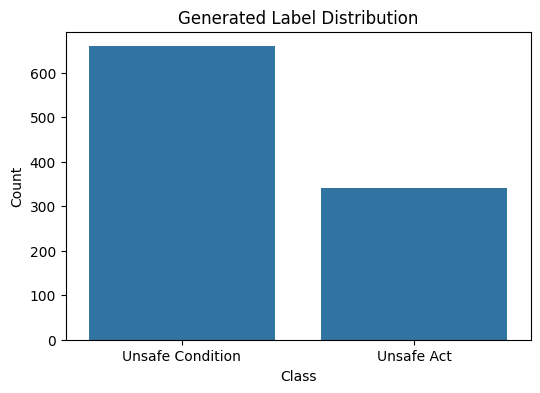

In [ ]:
# Display generated labels

print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Generated Label Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [ ]:
tie_records = df[
    df["condition_score"] == df["act_score"]
]

print("Number of tied records:", len(tie_records))

Number of tied records: 107


In [ ]:
print(
    "Percentage of tied records:",
    round(len(tie_records) / len(df) * 100, 2),
    "%"
)

Percentage of tied records: 10.7 %


In [ ]:
display(
    tie_records[
        [
            "SUMMARY",
            "cause",
            "fatcause",
            "condition_score",
            "act_score",
            "label"
        ]
    ].head(10)
)

,SUMMARY,cause,fatcause,condition_score,act_score,label
26,On October 20 2008 Employee #1 the owner of a painting contracting business was operating an aerial lift during the painting of the exterior walls of a parking garage and commercial building. The lift was boomed up and perpendicular to the chassis when it fell over backwards with Employee #1 restrained by a body harness and lanyard. The basket hit in the center divider of the adjoining street. Employee #1 was killed at the scene. The aerial lift was not properly rigged for elevated use. The axles supposed to be extended out to provide more stability. The system to prevent the elevation of the man basket without the extension of the axles was not operating.,Exterior painting,Fall from/with bucket,4,4,Unsafe Condition
42,"At approximately 8:00 am on April 2 2012 Employee #1 was drilling holes on the concrete decks (ceiling) approximately 13 feet high to hang wires for suspended ceiling tiles and securing the light fixtures. The hand-held rotary hammer (HILTI TE-2) used for drilling 3/8"" holes had been modified by removing its side handle and attaching it to a 9-foot pole along with a suction hose of a vacuum (to collect silica dust). The rotary hammer (and the vacuum) had to be switched on at the ground level and the hammer's ""lockbutton"" activated before it was raised to the ceiling. Employee #1 raised the pole toward the ceiling when the vacuum sucked in a piece of plastic draped around the ceiling fixture and wrapped around the running drill bit. He tried to remove the plastic with his left hand but the force of the running drill bit pulled his hand and amputated his 5th finger (middle and distal phalanges and nondisplaced fracture at residual base of the middle phalanx).",[],[],2,2,Unsafe Condition
72,At approximately 7:45 a.m. on November 7 2007 Employee #1 a carpenter with Sunset Structures Construction Inc. in Julian CA was using his own Makita drilling machine at its high-speed setting to cut a 0.75-in. hole. He pulled the machine out of the wood and it was coasting when the drill bit became entangled in the long sleeve of his flannel shirt striking his left forearm. He sustained a 1- to 1.5-in.-deep laceration and was transported immediately to a hospital for treatment. The employer had approximately six workers and owned most of the hand tools needed for construction activities. It also rented other equipment as needed and subcontracted other tasks.,Interior carpentry,Other,4,4,Unsafe Condition
73,On April 19 2008 Employee #1 climbed a ladder to the top of a hopper to check that three hoppers were being filling properly (two with gravel and one with sand). As he observed a conveyor belt filling sand into a hopper he fell into the hopper. Sand covered him and he died from asphyxiation.,Paving,Asphyxiation/inhalation of toxic vapor,1,1,Unsafe Condition
77,At approximately 5:00 p.m. on February 19 2004 an employee and a coworker were positioning a precast concrete slab on the second story of a motel. The slab weighed approximately 4 500 pounds. The slab tilted while the workers were standing on top of it. The employee was killed when the concrete slab fell on top of him. The coworker was able to jump to safety.,Pouring or installing floor decks,Fall,5,5,Unsafe Condition
80,At approximately 2:30 a.m. on July 23 2007 Employee #1 an electrician for All City Electric was in a scissor lift adjusting the lights at a Safeway store in Salinas CA. He climbed out of the lift and then was trying to climb back up the lift to lower it when he fell approximately 13 ft onto a grocery rack. Employee #1 suffered a hernia and was transported to Salinas Memorial Hospital where he was admitted for treatment.,[],Fall from/with bucket,2,2,Unsafe Condition
82,AN EMPLOYEE WAS HANDLING A DEFECTIVE ELECTRIC CORD FOR A PORTABLE HANDLAMP WHILE CLEANING THE INSIDE OF A BARGE WITH HIGH PRESSURE WATER. NO ONE WITNESSED THE ACCIDENT BUT A WELDING FOREMAN FOUND HIM LYING ON THE GROUND NEAR THE

In [ ]:
# Review generated labels

df[
    [
        "SUMMARY",
        "cause",
        "fatcause",
        "label"
    ]
].sample(10, random_state=42)

,SUMMARY,cause,fatcause,label
521,On March 18 2009 Employee #1 was coupling a rail car draw bar to a batter locomotive. He dropped the 300 pound draw bar on his right hand finger partially amputating it. Employee #1 was hospitalized.,Excavation,Crushed/run,Unsafe Condition
737,On May 2 2002 Employees #1 #2 #3 #4 and #5 were working on a cooling tower. The fan blades inside the cooling tower were unexpectedly energized and either threw the employees off to the decking or caused them to lose their footing. The employees sustained serious injuries and were hospitalized.,[],[],Unsafe Act
740,At approximately 7:30 a.m. on November 13 2009 Employee #1 a driver with A.M. Ortega Construction was loading a LeeBoy asphalt paving machine (Model Number 8510 Serial Number 48336) onto the back of a transport trailer at his employer's equipment yard. He drove the machine onto the trailer ramps while standing on the machine's platform adjacent to the controls. Employee #1 lost his balance and fell onto the controls which caused the machine to rotate. Before gaining control of the machine his right foot was caught between the rotating machine and the ground. Employee #1 was hospitalized at Kaiser Zion for a small toe amputation.,Paving,Crushed/run,Unsafe Act
660,At approximately 3:00 p.m. On February 19 2004 Employee #1 and five coworkers were installing trusses on the second floor of a two-story residential building. One of the coworkers was located on the ground rigging trusses to a crane while Employee #1 and four coworkers were located within the trusses of the second story waiting to receive the trusses for installation. The trusses measured approximately 35-feet long by 8-feet tall and were rigged at the top center point of the truss. As Employee #1 stood on the backside of the house within the trusses the crane began to lower a truss into place. When the truss was about 4 to 5 feet from being set on the top plate of the house it broke at the center and struck Employee #1 in the arm. He fell 25 feet to the ground. Employee #1 was hospitalized at a shock trauma center and treated for a cut on his left hand and a fractured spine and hip.,Roofing,Fall from/with structure,Unsafe Condition
411,At approximately 9:00 a.m. on September 20 2006 Employee #1 a framing carpenter was installing joists at an elevation of approximately 14 ft 9 in. above the ground during roof framing of a new light commercial building. Employee #1 was installing joists between a wall ledger and a beam located near the entry way area. As Employee #1 walked on top of a joist it gave way causing him to fall on to the concrete floor and his right knee struck a protruding 18-in. to 20-in. high by 2.5-in. wide by 0.375-in. thick metal stake causing a serious injury. Employee #1 was hospitalized for approximately six days.,Interior carpentry,Fall from roof,Unsafe Condition
678,On April 6 2001 an Employee was attempting to cut off the top of a 500-gallon underground storage tank to gain access sludge removal. The tank previously contained gasoline. Gasoline was mixed with water in the bottom of the tank that could not be removed by the vac truck device. The employee was cutting into the metal tank with a large gas powered saw which caused the residual vapors to ignited resulting in an explosion causing a fatal blast trauma injury to the employee.,[],Fire/explosion,Unsafe Act
626,At approximately 3:41 p.m. on June 4 2004 Employee #1 was installing a fuse on an energized 480-volt Zinsco Underwriter Laboratory Inc. panelboard for parking lot lights at a K-Mart in Newark CA. As he was working the lines sparked causing third-degree burns to both his hands and arms and second-degree burns to his face.,[],[],Unsafe Act
513,On November 29 1995 Employee #1 died of pneumonia after burning steel trusses. Legionella bacteria were found in the employee's urine but he had not been in good health and there was no indication that his immune system made any attempt to fight off the Legionnaire

In [ ]:
# Keep required columns

df = df[
    [
        "clean_summary",
        "label"
    ]
]

df.head()

,clean_summary,label
0,march employee three coworkers installing new skylight singlestory renovated warehouse new metal roof deck skylight hole covered plywood employee coworker started installing first skylight northwest roof corner pulled back plywood cover half skylight hole approximately set lower fiberglass panel installing insulating material employee inadvertently stepped skylight hole fiberglass bottom pan could support weight fell approximately concrete floor warehouse employee killed none crew member using personal fall protection system,Unsafe Condition
1,employee killed employee seriously injured hospitalized hek msm mast climbing work platform fell approximately foot ground employer failed ensure limit switch actuating rail also known red painted top mast installed supporting mast platform used red painted top mast actuates limit switch motor prevents platform traveling upwards portion mast missing platform prevented lifted beyond supporting mast falling ground,Unsafe Condition
2,may employee roofer coworker employed roofing contractor working residential building removed existing shake roof installing oriented strand board osb sheathing preparation installing composition roof roof pitch measured employee coworker removed approximately osb sheet stack sheet reason unknown brace identified one two osb sticker holding stack roof one sticker end stack broke ten sheet sheathing slid roof employee working stack struck falling sheet thrown roof fell eave height foot emergency service called sacramento fire department responded employee transported university california davis medical center sacramento treated compound fracture right wrist fractured hip fractured pelvis required four day hospitalization fall reported may sacramento fire department caloshas sacramento district office employer report subsequent investigation determined osb sheet stacked secured roof third party delivery company roofing crew inspected stack osb sheet morning reported secured,Unsafe Condition
3,february employee yearold male construction worker heldreth construction working approximately fortyfeet ground installing roof decking employee using harness retractable lanyard attached roof anchor fell force fall pulled anchor away decking attached allowing employee fall employee killed fall,Unsafe Condition
4,june employee well drilling inc drilling well water private residence operating drilling boring machine well drilled approximately foot well casing set depth foot inch diameter plastic grout pipe inserted outside well casing start filling grout grout tightened around bottom grout pipe pipe became stuck attempt extract pipe employee fastened steel chain sling around pipe hooked sling drill rig attempted hoist pipe broke broken pipe steel chain sling recoiled face employee transported hospital admitted treated cut fracture left eye fractured left cheek bone brain trauma,Unsafe Condition


In [ ]:
# Encode target labels

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

df.head()

['Unsafe Act' 'Unsafe Condition']


,clean_summary,label
0,march employee three coworkers installing new skylight singlestory renovated warehouse new metal roof deck skylight hole covered plywood employee coworker started installing first skylight northwest roof corner pulled back plywood cover half skylight hole approximately set lower fiberglass panel installing insulating material employee inadvertently stepped skylight hole fiberglass bottom pan could support weight fell approximately concrete floor warehouse employee killed none crew member using personal fall protection system,1
1,employee killed employee seriously injured hospitalized hek msm mast climbing work platform fell approximately foot ground employer failed ensure limit switch actuating rail also known red painted top mast installed supporting mast platform used red painted top mast actuates limit switch motor prevents platform traveling upwards portion mast missing platform prevented lifted beyond supporting mast falling ground,1
2,may employee roofer coworker employed roofing contractor working residential building removed existing shake roof installing oriented strand board osb sheathing preparation installing composition roof roof pitch measured employee coworker removed approximately osb sheet stack sheet reason unknown brace identified one two osb sticker holding stack roof one sticker end stack broke ten sheet sheathing slid roof employee working stack struck falling sheet thrown roof fell eave height foot emergency service called sacramento fire department responded employee transported university california davis medical center sacramento treated compound fracture right wrist fractured hip fractured pelvis required four day hospitalization fall reported may sacramento fire department caloshas sacramento district office employer report subsequent investigation determined osb sheet stacked secured roof third party delivery company roofing crew inspected stack osb sheet morning reported secured,1
3,february employee yearold male construction worker heldreth construction working approximately fortyfeet ground installing roof decking employee using harness retractable lanyard attached roof anchor fell force fall pulled anchor away decking attached allowing employee fall employee killed fall,1
4,june employee well drilling inc drilling well water private residence operating drilling boring machine well drilled approximately foot well casing set depth foot inch diameter plastic grout pipe inserted outside well casing start filling grout grout tightened around bottom grout pipe pipe became stuck attempt extract pipe employee fastened steel chain sling around pipe hooked sling drill rig attempted hoist pipe broke broken pipe steel chain sling recoiled face employee transported hospital admitted treated cut fracture left eye fractured left cheek bone brain trauma,1


In [ ]:
# Split dataset before applying TF-IDF

X_text = df["clean_summary"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train_text))
print("Testing Samples:", len(X_test_text))


# Convert training text into TF-IDF features

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)

# Transform test text using the training TF-IDF model
X_test = tfidf.transform(X_test_text)

print("Training Feature Matrix Shape:", X_train.shape)
print("Testing Feature Matrix Shape:", X_test.shape)

Training Samples: 800
Testing Samples: 200
Training Feature Matrix Shape: (800, 5000)
Testing Feature Matrix Shape: (200, 5000)


label
1    659
0    341
Name: count, dtype: int64


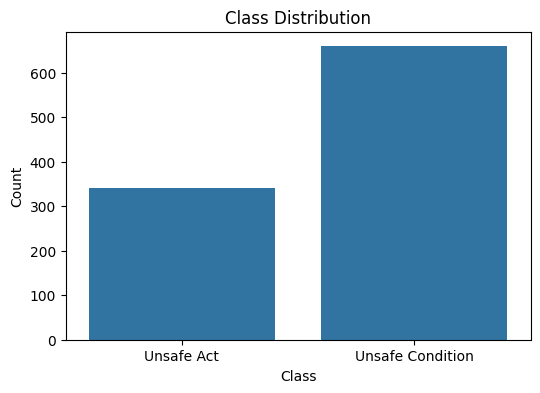

In [ ]:
# Display class distribution

print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["label"]
)

plt.xticks(
    [0, 1],
    label_encoder.classes_
)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [ ]:
# Calculate class weights

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.465201465201465), np.int64(1): np.float64(0.7590132827324478)}


In [ ]:
# Train Logistic Regression

lr_model = LogisticRegression(
    class_weight=class_weights,
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

print("\nClassification Report\n")
print(classification_report(
    y_test,
    lr_predictions,
    target_names=label_encoder.classes_
))

Accuracy : 0.695
Precision: 0.784
Recall   : 0.7424
F1 Score : 0.7626

Classification Report

                  precision    recall  f1-score   support

      Unsafe Act       0.55      0.60      0.57        68
Unsafe Condition       0.78      0.74      0.76       132

        accuracy                           0.69       200
       macro avg       0.67      0.67      0.67       200
    weighted avg       0.70      0.69      0.70       200



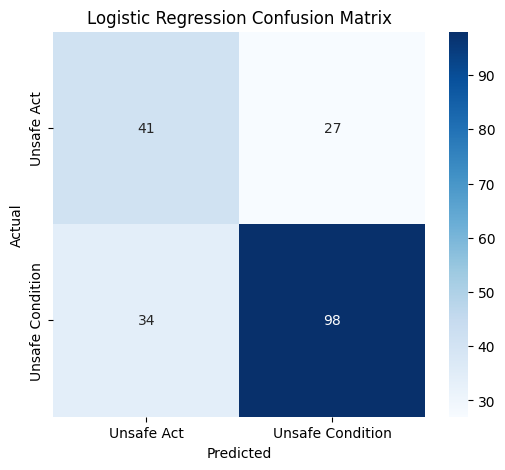

In [ ]:
# Logistic Regression Confusion Matrix

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Define evaluation function

def evaluate_model(model, X_test, y_test, predictions, model_name):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, "decision_function"):

        probabilities = model.decision_function(X_test)

    else:

        probabilities = model.predict(X_test).flatten()

    roc_auc = roc_auc_score(y_test, probabilities)

    pr_auc = average_precision_score(y_test, probabilities)

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")
    print(f"PR AUC    : {pr_auc:.4f}")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=label_encoder.classes_
        )
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axes[0]
    )

    axes[0].set_title(f"{model_name}\nConfusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    axes[1].plot(fpr, tpr, linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_title(f"ROC Curve\nAUC = {roc_auc:.4f}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")

    axes[2].plot(recall_curve, precision_curve, linewidth=2)
    axes[2].set_title(f"Precision-Recall Curve\nAUC = {pr_auc:.4f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    }

Logistic Regression
Accuracy  : 0.6950
Precision : 0.7840
Recall    : 0.7424
F1 Score  : 0.7626
ROC AUC   : 0.7812
PR AUC    : 0.8786

Classification Report

                  precision    recall  f1-score   support

      Unsafe Act       0.55      0.60      0.57        68
Unsafe Condition       0.78      0.74      0.76       132

        accuracy                           0.69       200
       macro avg       0.67      0.67      0.67       200
    weighted avg       0.70      0.69      0.70       200



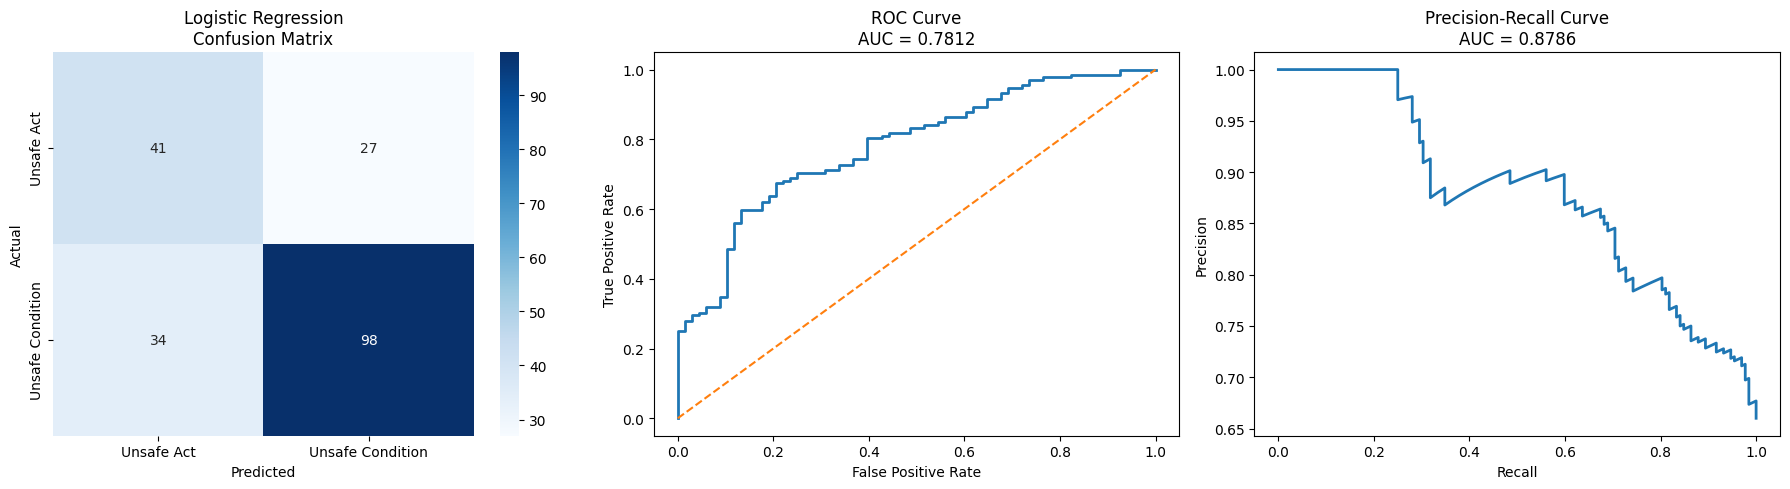

In [ ]:
# Evaluate Logistic Regression

lr_results = evaluate_model(
    lr_model,
    X_test,
    y_test,
    lr_predictions,
    "Logistic Regression"
)

In [ ]:
# Train Support Vector Machine

svm_model = LinearSVC(
    class_weight=class_weights,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

print("Support Vector Machine trained successfully.")

Support Vector Machine trained successfully.


Support Vector Machine
Accuracy  : 0.7150
Precision : 0.7953
Recall    : 0.7652
F1 Score  : 0.7799
ROC AUC   : 0.7756
PR AUC    : 0.8748

Classification Report

                  precision    recall  f1-score   support

      Unsafe Act       0.58      0.62      0.60        68
Unsafe Condition       0.80      0.77      0.78       132

        accuracy                           0.71       200
       macro avg       0.69      0.69      0.69       200
    weighted avg       0.72      0.71      0.72       200



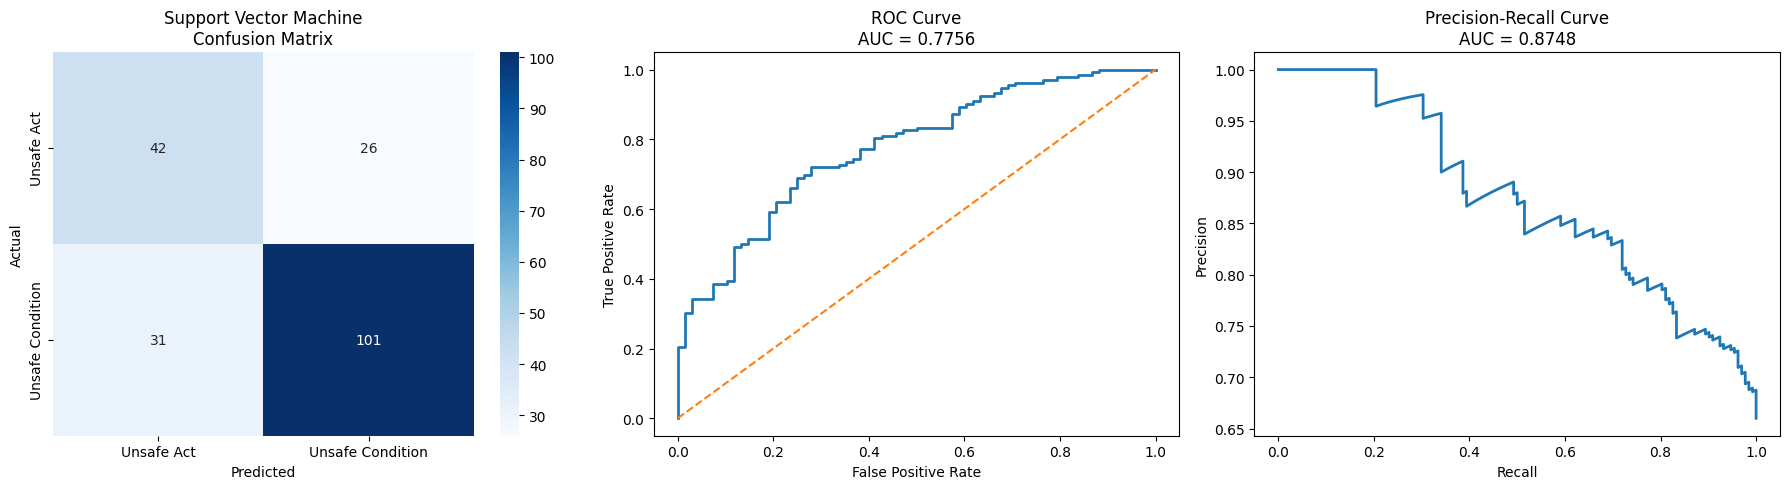

In [ ]:
# Evaluate Support Vector Machine

svm_results = evaluate_model(
    svm_model,
    X_test,
    y_test,
    svm_predictions,
    "Support Vector Machine"
)

In [ ]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


Random Forest
Accuracy  : 0.7250
Precision : 0.7333
Recall    : 0.9167
F1 Score  : 0.8148
ROC AUC   : 0.7983
PR AUC    : 0.8939

Classification Report

                  precision    recall  f1-score   support

      Unsafe Act       0.69      0.35      0.47        68
Unsafe Condition       0.73      0.92      0.81       132

        accuracy                           0.72       200
       macro avg       0.71      0.63      0.64       200
    weighted avg       0.72      0.72      0.70       200



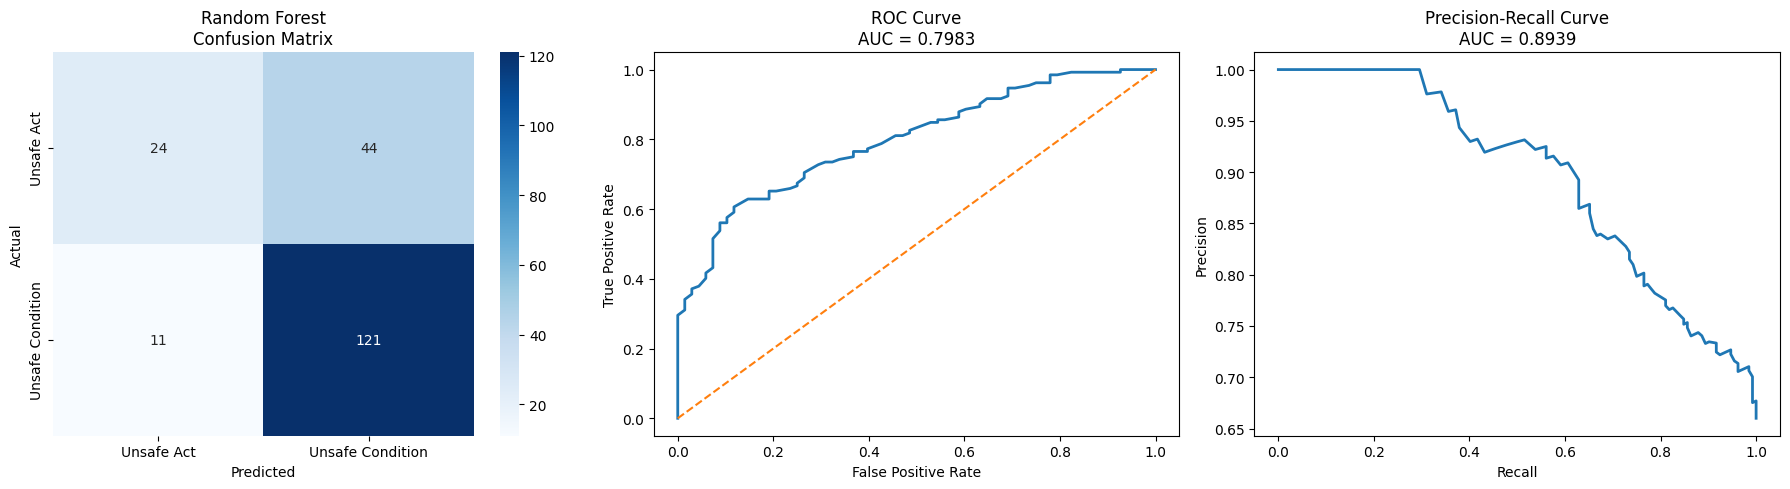

In [ ]:
# Evaluate Random Forest

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    rf_predictions,
    "Random Forest"
)

In [ ]:
# Import TensorFlow libraries

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.utils import plot_model

In [ ]:
# Build neural network

ann_model = Sequential()

ann_model.add(
    Dense(
        256,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)

ann_model.add(
    Dropout(0.3)
)

ann_model.add(
    Dense(
        128,
        activation="relu"
    )
)

ann_model.add(
    Dropout(0.3)
)

ann_model.add(
    Dense(
        64,
        activation="relu"
    )
)

ann_model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

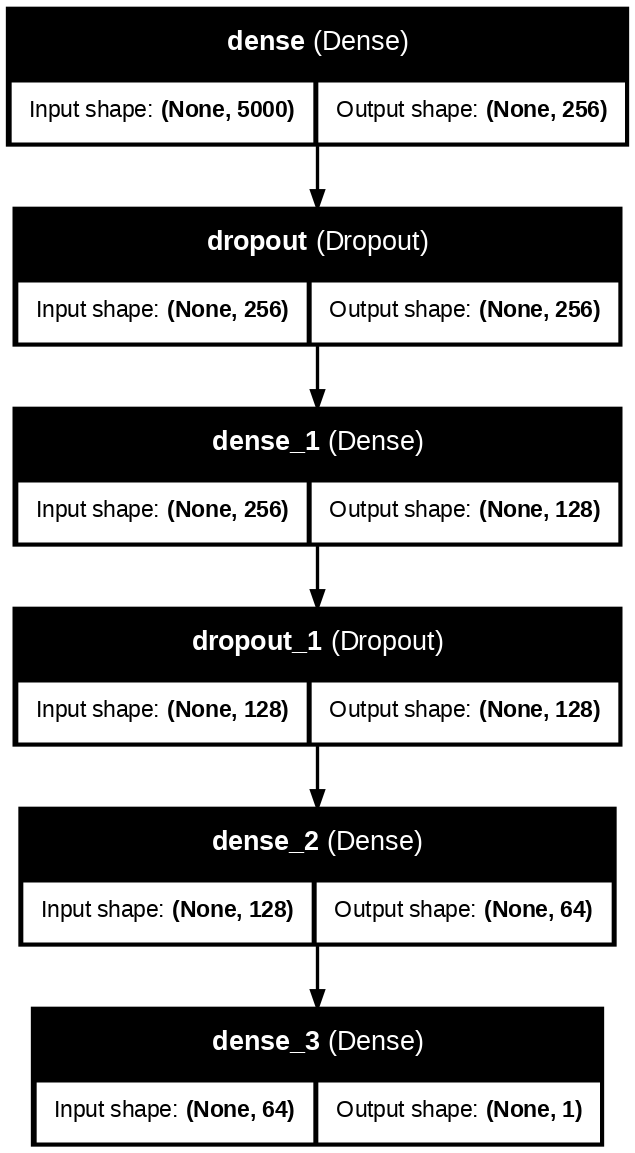

In [ ]:
# Display neural network architecture

plot_model(
    ann_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=120
)

In [ ]:
# Train neural network

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train.toarray(),
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4547 - loss: 0.6870 - precision: 0.7532 - recall: 0.2717 - val_accuracy: 0.7125 - val_loss: 0.6810 - val_precision: 0.7109 - val_recall: 0.9100
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8609 - loss: 0.6194 - precision: 0.9311 - recall: 0.8548 - val_accuracy: 0.7375 - val_loss: 0.5885 - val_precision: 0.7636 - val_recall: 0.8400
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9266 - loss: 0.2991 - precision: 0.9545 - recall: 0.9344 - val_accuracy: 0.7437 - val_loss: 0.6203 - val_precision: 0.7864 - val_recall: 0.8100
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9922 - loss: 0.0477 - precision: 0.9976 - recall: 0.9906 - val_accuracy: 0.7312 - val_loss: 0.8793 - val_precision: 0.7714 - val_recall: 0.8100
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0067 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.7437 - val_loss: 1.0196 

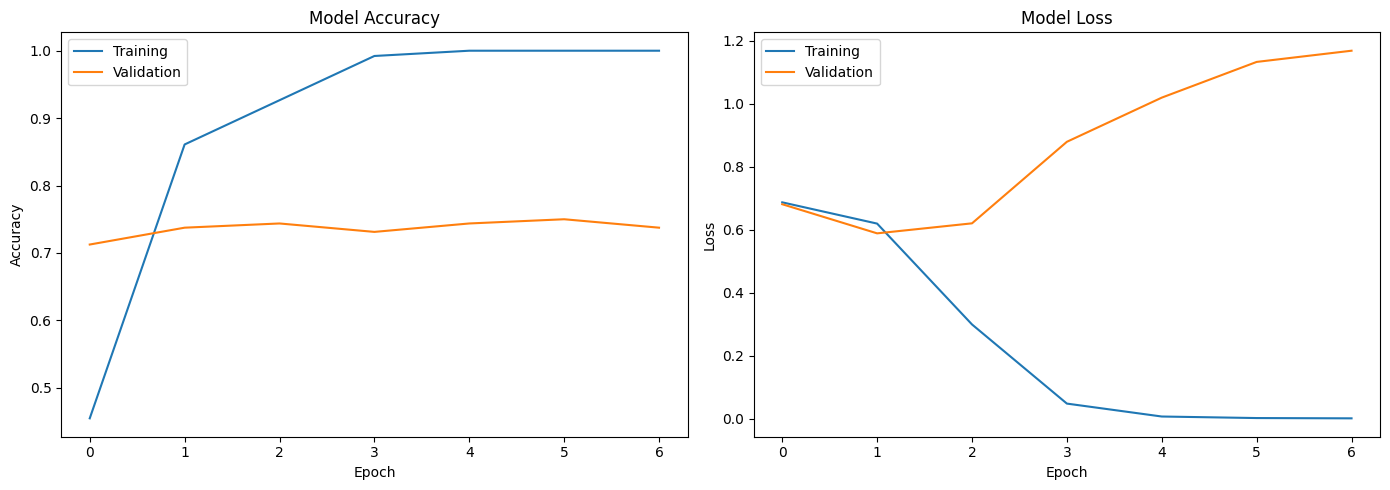

In [ ]:
# Plot training history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()

plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Artificial Neural Network
Accuracy  : 0.7250
Precision : 0.7730
Recall    : 0.8258
F1 Score  : 0.7985
ROC AUC   : 0.7702
PR AUC    : 0.8648

Classification Report

                  precision    recall  f1-score   support

      Unsafe Act       0.61      0.53      0.57        68
Unsafe Condition       0.77      0.83      0.80       132

        accuracy                           0.72       200
       macro avg       0.69      0.68      0.68       200
    weighted avg       0.72      0.72      0.72       200



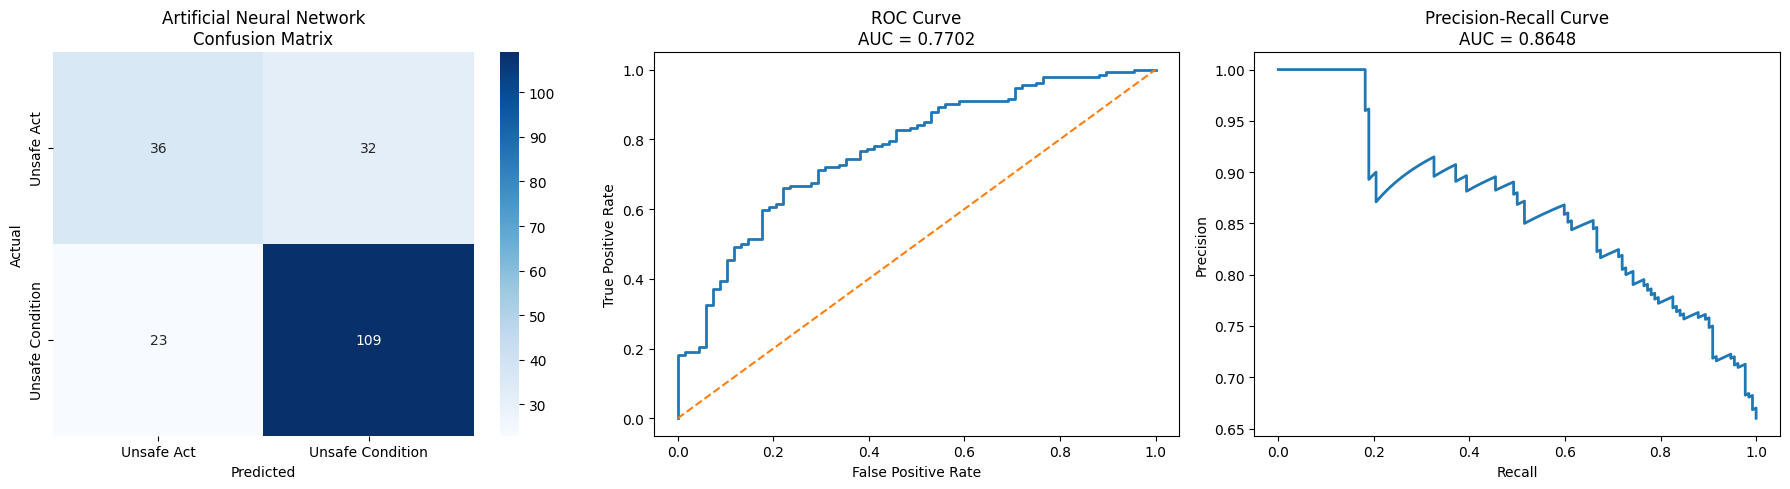

In [ ]:
# Predict using neural network

ann_probabilities = ann_model.predict(X_test.toarray())

ann_predictions = (
    ann_probabilities > 0.5
).astype(int).flatten()

ann_results = evaluate_model(
    ann_model,
    X_test.toarray(),
    y_test,
    ann_predictions,
    "Artificial Neural Network"
)

In [ ]:
# Compare model performance

results = pd.DataFrame([
    lr_results,
    svm_results,
    rf_results,
    ann_results
])

results = results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Random Forest,0.725,0.733333,0.916667,0.814815,0.798295,0.893866
1,Artificial Neural Network,0.725,0.773050,0.825758,0.798535,0.770165,0.864818
2,Support Vector Machine,0.715,0.795276,0.765152,0.779923,0.775624,0.874833
3,Logistic Regression,0.695,0.784000,0.742424,0.762646,0.781194,0.878564


In [ ]:
# Save model comparison

results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


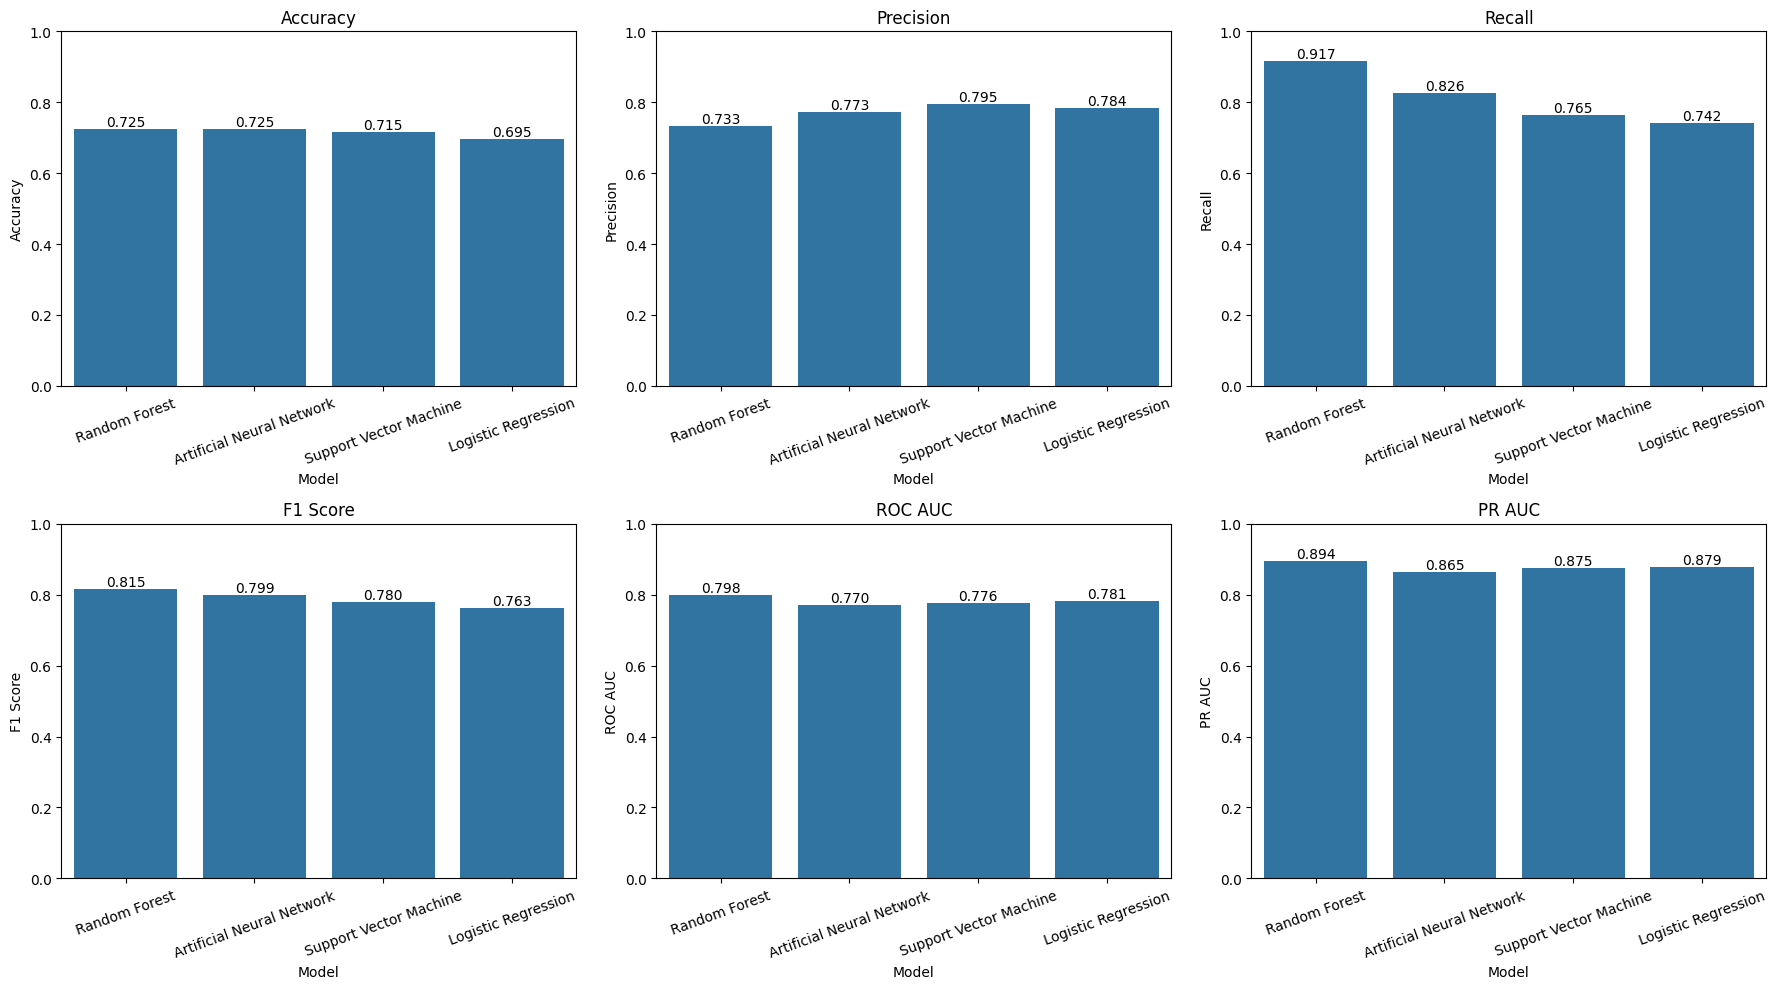

In [ ]:
# Visualize model performance

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "PR AUC"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, metric in enumerate(metrics):

    sns.barplot(
        data=results,
        x="Model",
        y=metric,
        ax=axes[i]
    )

    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.3f")

    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()

plt.show()

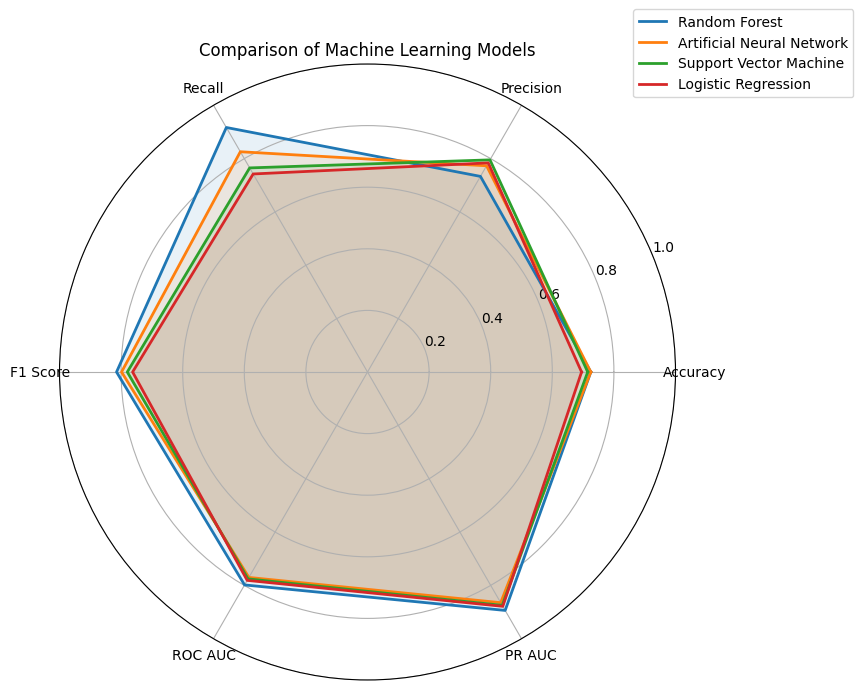

In [ ]:
# Radar chart for model comparison

categories = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "PR AUC"
]

num_vars = len(categories)

angles = np.linspace(
    0,
    2 * np.pi,
    num_vars,
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(8, 8))

ax = plt.subplot(111, polar=True)

for _, row in results.iterrows():

    values = [
        row["Accuracy"],
        row["Precision"],
        row["Recall"],
        row["F1 Score"],
        row["ROC AUC"],
        row["PR AUC"]
    ]

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(0, 1)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1)
)

plt.title("Comparison of Machine Learning Models")

plt.show()

In [ ]:
# Display best performing model

best_model = results.iloc[0]

print("Best Model")

print(best_model)

Best Model
Model        Random Forest
Accuracy             0.725
Precision         0.733333
Recall            0.916667
F1 Score          0.814815
ROC AUC           0.798295
PR AUC            0.893866
Name: 0, dtype: object


In [ ]:
# Install Plotly

!pip install plotly -q

In [ ]:
# Import Plotly

import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Interactive confusion matrix

cm = confusion_matrix(
    y_test,
    lr_predictions
)

fig = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale="Blues",
    x=label_encoder.classes_,
    y=label_encoder.classes_,
    labels={
        "x": "Predicted Label",
        "y": "Actual Label",
        "color": "Count"
    },
    title="Interactive Confusion Matrix"
)

fig.update_layout(
    width=700,
    height=600
)

fig.show()

In [ ]:
# Interactive prediction explorer

prediction_df = pd.DataFrame({

    "Narrative": df.loc[y_test.index, "clean_summary"].values,

    "Actual Label": label_encoder.inverse_transform(y_test),

    "Predicted Label": label_encoder.inverse_transform(lr_predictions)

})

prediction_df["Prediction"] = np.where(

    prediction_df["Actual Label"] ==
    prediction_df["Predicted Label"],

    "Correct",

    "Incorrect"

)

prediction_df.head()

,Narrative,Actual Label,Predicted Label,Prediction
0,employee sustained amputation left thumb glove left hand got caught rotating drill bit milling machine drill press,Unsafe Condition,Unsafe Condition,Correct
1,employee running crane boom boom rolled struck basket working wearing harness tied fell died,Unsafe Condition,Unsafe Condition,Correct
2,approximately november employee csteel erectors straddling horizontal ibeam approximately ground level employee connecting vertical member horizontal ibeams located southwest corner worksite torquing bolt right hand wrench wrench lost contact bolt employee lost balance process subsequently fell ground employee transported via helicopter local hospital later died result injury sustained fall,Unsafe Condition,Unsafe Condition,Correct
3,january employee connector fell approximately foot steel erection process trying make connection wearing appropriate fall protection equipment equipment tied time accident died scene,Unsafe Condition,Unsafe Condition,Correct
4,employee crushed hand working escalator employee suffered laceration treated injury hospitalized information provided report,Unsafe Act,Unsafe Condition,Incorrect


In [ ]:
# Interactive prediction table

fig = go.Figure(

    data=[
        go.Table(

            header=dict(

                values=list(prediction_df.columns),

                fill_color="royalblue",

                font=dict(color="white", size=12),

                align="left"

            ),

            cells=dict(

                values=[

                    prediction_df["Narrative"],

                    prediction_df["Actual Label"],

                    prediction_df["Predicted Label"],

                    prediction_df["Prediction"]

                ],

                align="left"

            )

        )

    ]

)

fig.update_layout(

    title="Interactive Prediction Explorer"

)

fig.show()

In [ ]:
# Prediction probability distribution

probabilities = lr_model.predict_proba(X_test)[:, 1]

probability_df = pd.DataFrame({

    "Probability": probabilities,

    "Actual Label": label_encoder.inverse_transform(y_test)

})

fig = px.histogram(

    probability_df,

    x="Probability",

    color="Actual Label",

    nbins=30,

    marginal="box",

    title="Prediction Probability Distribution"

)

fig.show()